# Sentiment Analysis - Baseline Model

This notebook explores the IMDb dataset and evaluates baseline NLP models:
- TF-IDF + Logistic Regression
- TF-IDF + Linear SVM

In [11]:
import pandas as pd

df = pd.read_csv("../data/raw/IMDB Dataset.csv")
df.head()

df.shape
df["sentiment"].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

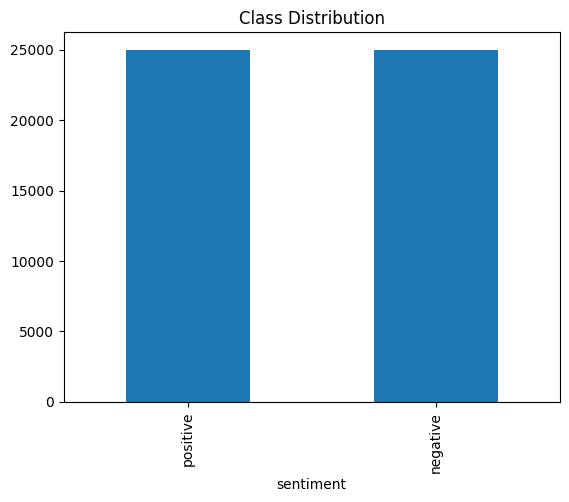

In [12]:
import matplotlib.pyplot as plt

df["sentiment"].value_counts().plot(kind="bar")
plt.title("Class Distribution")
plt.show()

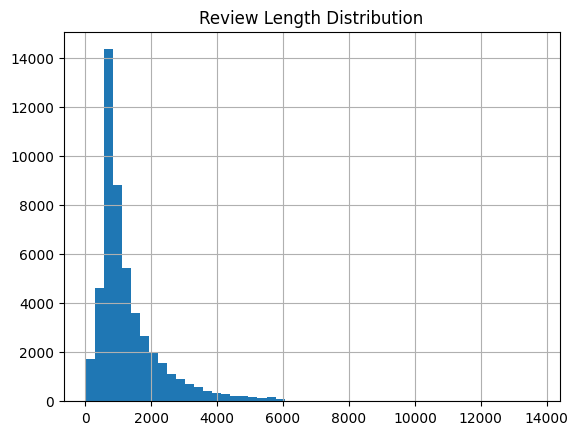

In [13]:
df["length"] = df["review"].apply(len)

df["length"].hist(bins=50)
plt.title("Review Length Distribution")
plt.show()

In [14]:
import sys
import os

sys.path.append(os.path.abspath("../src"))

from preprocess import clean_text

sample = df["review"].iloc[0]

print("Original:\n", sample)
print("\nCleaned:\n", clean_text(sample))

Original:
 One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due

In [15]:
train_df = pd.read_csv("../data/processed/train.csv")
test_df = pd.read_csv("../data/processed/test.csv")

train_df.shape, test_df.shape

((40000, 3), (10000, 3))

In [16]:
with open("../outputs/reports/model_comparison.txt", "r", encoding="utf-8") as f:
    print(f.read())

==================== Logistic Regression ====================
Accuracy: 0.9112

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.91      0.91      5000
           1       0.91      0.92      0.91      5000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000

Confusion Matrix:
[[4525  475]
 [ 413 4587]]

==================== Linear SVM ====================
Accuracy: 0.9090

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.90      0.91      5000
           1       0.91      0.91      0.91      5000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000

Confusion Matrix:
[[4521  479]
 [ 431 4569]]

Best Model: Logistic Regression | Accuracy: 0.9112



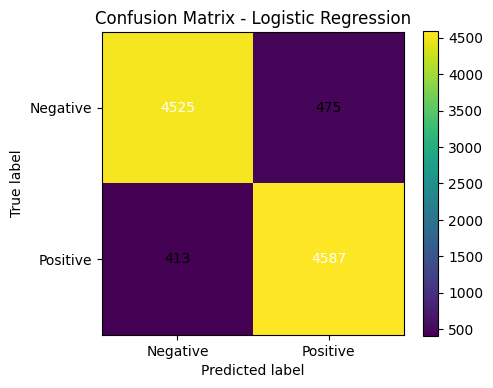

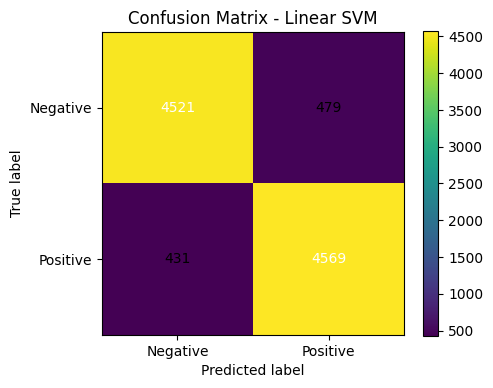

In [17]:
from PIL import Image

img = Image.open("../outputs/figures/logistic_regression_confusion_matrix.png")
display(img)

img = Image.open("../outputs/figures/linear_svm_confusion_matrix.png")
display(img)

In [18]:
with open("../outputs/reports/model_disagreements.txt", "r", encoding="utf-8") as f:
    print(f.read()[:2000])  # ilk kısmı göster

Example 1
True Label: 0
Logistic Prediction: 1
SVM Prediction: 0
Text: The movie 'Gung Ho!': The Story of Carlson's Makin Island Raiders was made in 1943 with a view to go up the moral of American people at the duration of second world war. It shows with the better way that the cinema can constitute body of propaganda. The value of this film is only collection and no artistic. In a film of propaganda it is useless to judge direction and actors. Watch that movie if you are interested to learn how propaganda functions in the movies or if you are a big fun of Robert Mitchum who has a small role in the film. If you want to see a film for the second world war, they exist much better and objective. I rated it 4/10.
--------------------------------------------------------------------------------
Example 2
True Label: 0
Logistic Prediction: 1
SVM Prediction: 0
Text: After having watched Darwin's Nightmare, one must have the impression of Tanzania being a living hell, with its population being 

In [1]:
from transformers import pipeline

classifier = pipeline(
    "text-classification",
    model="../models/bert_sentiment",
    tokenizer="../models/bert_sentiment"
)

texts = [
    "This movie was absolutely amazing!",
    "I hated every minute of this film.",
    "The acting was good but the story was boring."
]

for text in texts:
    result = classifier(text)[0]
    print(text)
    print(result)
    print()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

This movie was absolutely amazing!
{'label': 'positive', 'score': 0.9996410608291626}

I hated every minute of this film.
{'label': 'negative', 'score': 0.9995647072792053}

The acting was good but the story was boring.
{'label': 'negative', 'score': 0.9991003274917603}



## Example Comparison

Sentence:
"The movie was not bad"

- Logistic Regression: Negative ❌
- SVM: Negative ❌
- BERT: Positive ✅

BERT correctly understands negation.

## Model Comparison

| Model | Accuracy | Notes |
|------|--------|------|
| Logistic Regression | ~0.91 | Fast, strong baseline |
| Linear SVM | ~0.90 | Slightly better |
| BERT | ~0.92+ | Best performance, understands context |

### Observations
- Traditional models perform surprisingly well
- BERT handles complex sentences better